
## **DNN ASSIGNMENT Group No 163**

## Group Member Names:
1. ABHIJIT DEY(2024AA05076)
2. GAURAV DHAMI (2024AA05077)
3. MANISH GARG (2024AA05118)
4. SUKAMATI NAVEEN KUMAR (2024AA05078)

# 1. Import the required libraries

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from keras.models import Sequential
from keras.layers import Dense, Activation, BatchNormalization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Data Acquisition  -- Score: 0.5 Mark
**Points noted from the data set selected CIFAR10**

1.   We choose Cifar10 data set because it is widely used and having diverse set of colour images, making us to explore and evaluate DNN parameters in better way.
2.   Data set has 60000 coloured images and 10 different classes.
3.   We found the dataset to be challenging and interesting because the images are small and contain a lot of variation in backgrounds, colors, and object positions. This makes it a good test for the learning ability of deep neural networks.
4.   The dataset is split into 50,000 training images and 10,000 test images, which allowed us to properly train our model and then evaluate its performance on unseen data.





## 2.1 Code for converting the above downloaded data into a form suitable for DL



In [18]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(f"Training samples: {x_train.shape}, Test samples: {x_test.shape}")

Training samples: (50000, 32, 32, 3), Test samples: (10000, 32, 32, 3)


## 2.1 Write your observations from the above.

1. **Size of the dataset**
    
    The CIFAR-10 dataset consists of 60,000 color images in total.
    **Training set**: 50,000 images
    **Test set**: 10,000 images
    Each image is of size 32x32 pixels with 3 color channels RGB.
2. **What type of data attributes are there?**
    
    **Features**: The data consists of small color images (numerical pixel values) with three channels (Red, Green, Blue), each pixel value ranging from 0 to 255. After preprocessing, these are normalized to the range 0 to 1 and flattened into vectors of length 3072 (32 × 32 × 3).

    **Labels**: The target variable is categorical, representing one of 10 classes (e.g., airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
3. What are you classifying?:

    We are classifying each image into one of 10 categories. The goal is to predict the correct class label for each input image based on its pixel values
4. Plot the distribution of the categories of the target / label.



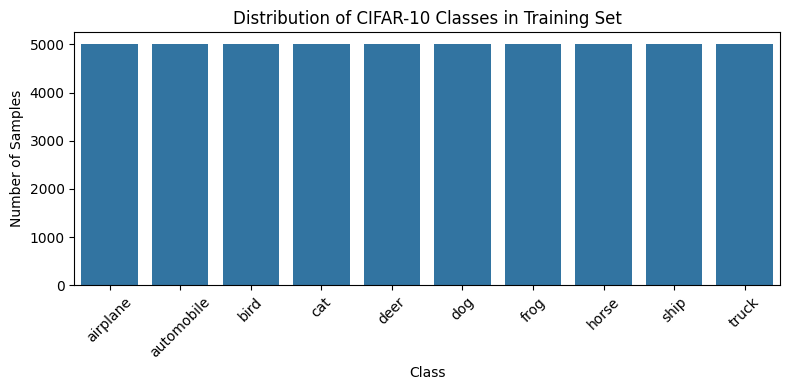

In [19]:
# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Flatten y_train to 1D array for counting
y_train_flattened = y_train.flatten()

# Plot the distribution
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_flattened)
plt.title('Distribution of CIFAR-10 Classes in Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(ticks=np.arange(10), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()


# 3. Data Preparation -- Score: 1 Mark

Perform the data prepracessing that is required for the data that you have downloaded.

This stage depends on the dataset that is used.

## 3.1 Apply pre-processing techiniques

# Below are the preprocessing techniques applied

1.   Normalization
2.   Flattening
3.   One-hot Encoding


In [20]:
# normalize the data
x_train = x_train / 255.0
x_test = x_test / 255.0
# flattening the data
x_train_flat = x_train.reshape(-1, 32 * 32 * 3)
x_test_flat = x_test.reshape(-1, 32 * 32 * 3)
print(f"Flattened shape: {x_train_flat.shape}")

Flattened shape: (50000, 3072)


## 3.2 Identify the target variables.

* Separate the data front the target such that the dataset is in the form of (X,y) or (Features, Label)

* Discretize / Encode the target variable or perform one-hot encoding on the target or any other as and if required.





In [21]:
# Convert integer labels to one-hot vectors for multi-class classification
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

## 3.3 Split the data into training set and testing set

The size of the training and testing datasets for CIFAR-10 in our assignment is:
Training dataset: 50,000 samples (images)
Testing dataset: 10,000 samples (images)
Splitted as 80% training data and 20% test data

## 3.4 Preprocessing report




* We did normalization and flattening along with categorical encoding
* We scaled pixel values to improve numerical stability and conevrted 3D image data to 1D vector
* converted integer labels to one-hot vectors for multi-class classification
* Data is clean and no duplicate data found
* The size of the training and testing datasets for CIFAR-10 in our assignment is:
Training dataset: 50,000 samples (images)
Testing dataset: 10,000 samples (images)

# 4. Deep Neural Network Architecture - Score:  Marks


## 4.1 Design the architecture that you will be using

* Sequential Model Building with Activation for each layer.
* Add dense layers, specifying the number of units in each layer and the activation function used in the layer.
* Use Relu Activation function in each hidden layer
* Use Sigmoid / softmax Activation function in the output layer as required

DO NOT USE CNN OR RNN.

In [22]:

model = Sequential([
    Dense(1024, activation='relu', input_shape=(3072,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 4.2 DNN Report

Report the following and provide justification for the same.



* Number of layers
* Number of units in each layer
* Total number of trainable parameters



# Number of layers

 The model contains 5 Dense layers (one output layer with softmax)

# Number of units in each layer

    Layer	  Units
    1   	  1024
    2	      512
    3	      256
    4	      128
    5	      10

# Total number of trainable parameters

## Trainable parameters = (n_input × n_output) + n_output (bias)

Input → 1024 units:
(
3072
×
1024
)
+
1024
=
3
,
146
,
752
(3072×1024)+1024=3,146,752

1024 → 512 units:
(
1024
×
512
)
+
512
=
524
,
800
(1024×512)+512=524,800

512 → 256 units:
(
512
×
256
)
+
256
=
131
,
328
(512×256)+256=131,328

256 → 128 units:
(
256
×
128
)
+
128
=
32
,
896
(256×128)+128=32,896

128 → 10 units:
(
128
×
10
)
+
10
=
1
,
290
(128×10)+10=1,290

Total:
3
,
146
,
752
+
524
,
800
+
131
,
328
+
32
,
896
+
1
,
290
=
3
,
837
,
066
3,146,752+524,800+131,328+32,896+1,290=3,837,066

# Why we used softmax instead of sigmoid
We used Softmax for the output layer because our dataset (CIFAR-10) is a multi-class classification problem with 10 different classes.
Softmax gives a probability for each class and ensures the sum is 1, making it easy to pick the most likely class, while sigmoid is mainly used for binary (two-class) problems and does not ensure the outputs sum to 1 across multiple classes.

# 5. Training the model - Score: 1 Mark


## 5.1 Configure the training

Configure  the model for training, by using appropriate optimizers and regularizations

Compile with categorical CE loss and metric accuracy.

In [23]:
# --- Compile the Model ---
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## 5.2 Train the model

Train Model with cross validation, with total time taken shown for 20 epochs.

Use SGD.

In [24]:
# --- Train the Model ---
history = model.fit(x_train_flat, y_train_cat,
                    epochs=20,
                    batch_size=128,
                    validation_split=0.2,
                    verbose=2)

Epoch 1/20
313/313 - 4s - 13ms/step - accuracy: 0.2673 - loss: 2.0328 - val_accuracy: 0.3072 - val_loss: 1.9195
Epoch 2/20
313/313 - 3s - 9ms/step - accuracy: 0.3434 - loss: 1.8451 - val_accuracy: 0.3502 - val_loss: 1.8233
Epoch 3/20
313/313 - 3s - 8ms/step - accuracy: 0.3726 - loss: 1.7659 - val_accuracy: 0.3903 - val_loss: 1.7349
Epoch 4/20
313/313 - 1s - 4ms/step - accuracy: 0.3948 - loss: 1.7099 - val_accuracy: 0.3564 - val_loss: 1.8073
Epoch 5/20
313/313 - 2s - 8ms/step - accuracy: 0.4136 - loss: 1.6614 - val_accuracy: 0.3967 - val_loss: 1.6923
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.4264 - loss: 1.6232 - val_accuracy: 0.3899 - val_loss: 1.7421
Epoch 7/20
313/313 - 2s - 5ms/step - accuracy: 0.4355 - loss: 1.5944 - val_accuracy: 0.4169 - val_loss: 1.6339
Epoch 8/20
313/313 - 2s - 8ms/step - accuracy: 0.4482 - loss: 1.5623 - val_accuracy: 0.4391 - val_loss: 1.6048
Epoch 9/20
313/313 - 2s - 8ms/step - accuracy: 0.4546 - loss: 1.5402 - val_accuracy: 0.3718 - val_loss: 1.7690


Justify your choice of optimizers and regulizations used and the hyperparameters tuned


1. We used Stochastic Gradient Descent as our primary optimizer, as required in the assignment instructions for the initial experiments.
2. In later experiments, we also tried Adam and RMSProp optimizers.
3. Adam is particularly well-suited for large datasets and high-dimensional parameter spaces like CIFAR-10. It adapts the learning rate for each parameter, often leading to faster convergence and better overall performance compared to plain SGD.We got little higher accuracy than SGD while using adam.
4. We applied Dropout after each Dense layer to prevent overfitting
5. Batch Normalization was included after each Dense layer.
6. We experimented with L2 regularization in same model.
7. The hyper parametrs like leaerning rate, drop out rate along with batch size we tuned with different parameters and verified the model training and test accuracy.

# 6. Test the model - 0.5 marks


In [25]:
# --- Evaluate on Test Data ---
test_loss, test_acc = model.evaluate(x_test_flat, y_test_cat, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.4910 - loss: 1.4321
Test accuracy: 0.4910
Test Loss: 1.4321


# 7. Intermediate result  - Score: 1 mark

1. Plot the training and validation accuracy history.
2. Plot the training and validation loss history.
3. Report the testing accuracy and loss.
4. Show Confusion Matrix for testing dataset.
5. Report values for preformance study metrics like accuracy, precision, recall, F1 Score.


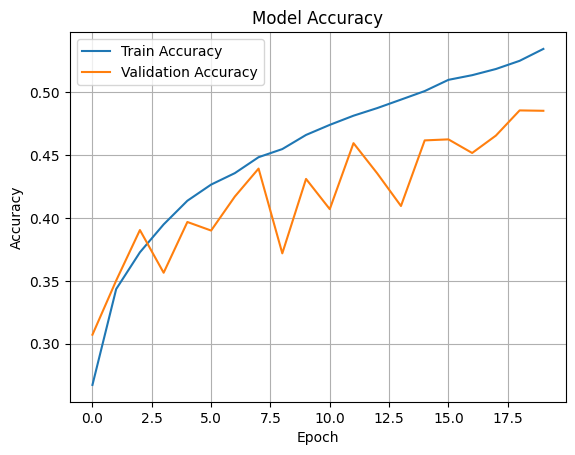

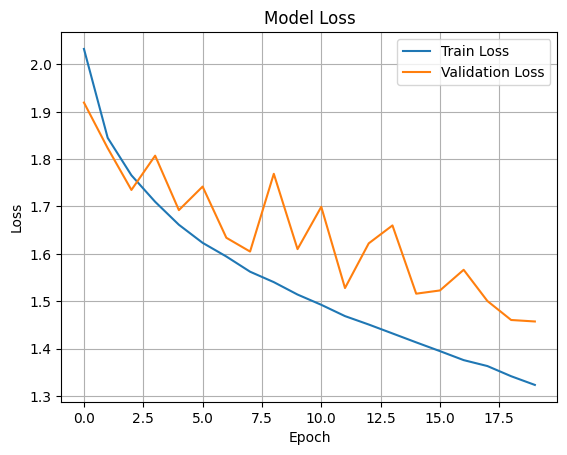

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 800x800 with 0 Axes>

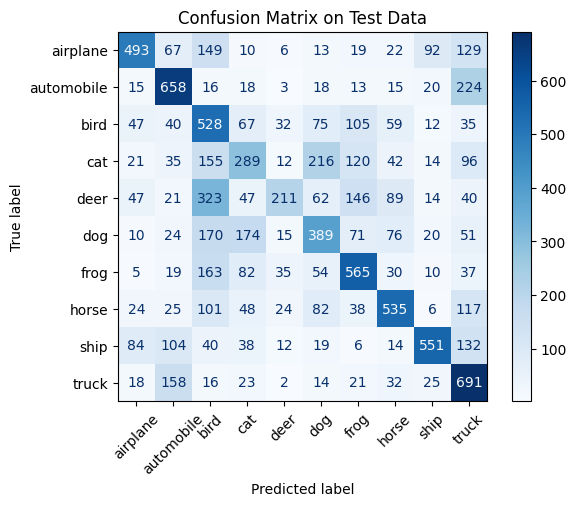

Test Accuracy: 0.4910
Precision (macro): 0.5174
Recall (macro): 0.4910
F1 Score (macro): 0.4865

Classification Report:

              precision    recall  f1-score   support

    airplane       0.65      0.49      0.56      1000
  automobile       0.57      0.66      0.61      1000
        bird       0.32      0.53      0.40      1000
         cat       0.36      0.29      0.32      1000
        deer       0.60      0.21      0.31      1000
         dog       0.41      0.39      0.40      1000
        frog       0.51      0.56      0.54      1000
       horse       0.59      0.54      0.56      1000
        ship       0.72      0.55      0.62      1000
       truck       0.45      0.69      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.52      0.49      0.49     10000
weighted avg       0.52      0.49      0.49     10000



In [26]:
# --- Plot Training and Validation Accuracy ---
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()
# --- Plot Training and Validation Loss ---
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.show()

# Predict class probabilities and get class labels
y_pred_probs = model.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
])
plt.figure(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Data")
plt.show()

# Accuracy
test_accuracy = accuracy_score(y_true_classes, y_pred_classes)
# Precision, Recall, F1 Score (macro average)
precision = precision_score(y_true_classes, y_pred_classes, average='macro')
recall = recall_score(y_true_classes, y_pred_classes, average='macro')
f1 = f1_score(y_true_classes, y_pred_classes, average='macro')

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1 Score (macro): {f1:.4f}")

# Optional: Full classification report
print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=[
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]))

# 8. Model architecture - Score: 1 mark


Modify the architecture designed in section 4.1

1. by decreasing one layer
2. by increasing one layer

For example, if the architecture in 4.1 has 5 layers, then 8.1 should have 4 layers and 8.2 should have 6 layers.

Plot the comparison of the training and validation accuracy of the three architecures (4.1, 8.1 and 8.2)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
313/313 - 3s - 10ms/step - accuracy: 0.2797 - loss: 2.0291 - val_accuracy: 0.3296 - val_loss: 1.9026
Epoch 2/20
313/313 - 1s - 4ms/step - accuracy: 0.3492 - loss: 1.8363 - val_accuracy: 0.3488 - val_loss: 1.8311
Epoch 3/20
313/313 - 3s - 9ms/step - accuracy: 0.3784 - loss: 1.7603 - val_accuracy: 0.3744 - val_loss: 1.7602
Epoch 4/20
313/313 - 2s - 5ms/step - accuracy: 0.3991 - loss: 1.7049 - val_accuracy: 0.3616 - val_loss: 1.7791
Epoch 5/20
313/313 - 2s - 7ms/step - accuracy: 0.4125 - loss: 1.6603 - val_accuracy: 0.3809 - val_loss: 1.7537
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.4282 - loss: 1.6202 - val_accuracy: 0.4135 - val_loss: 1.6547
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4375 - loss: 1.5913 - val_accuracy: 0.4155 - val_loss: 1.6522
Epoch 8/20
313/313 - 3s - 8ms/step - accuracy: 0.4479 - loss: 1.5614 - val_accuracy: 0.3898 - val_loss: 1.6774
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4585 - loss: 1.5366 - val_accuracy: 0.4243 - val_loss: 1.6165


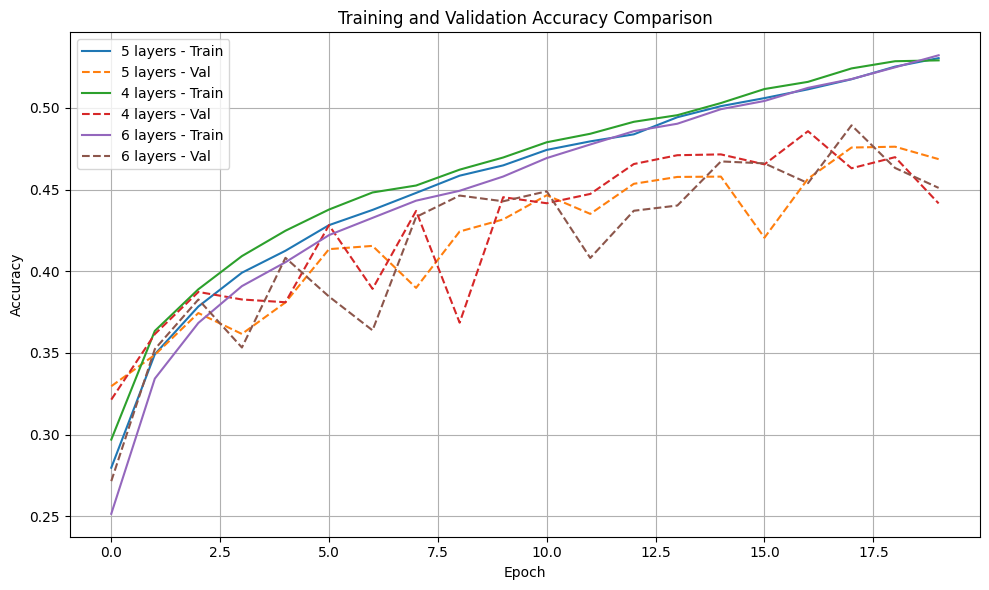

In [27]:
# Original: 5 Dense layers (Section 4.1)
def build_model_original():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Decreased by one: 4 Dense layers
def build_model_minus1():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Increased by one: 6 Dense layers
def build_model_plus1():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),  # Added extra Dense layer
        Dense(10, activation='softmax')
    ])
    return model

# Compile settings
optimizer = 'sgd'
loss = 'categorical_crossentropy'
metrics = ['accuracy']

# Store histories for plotting
histories = {}

# Original model
model_orig = build_model_original()
model_orig.compile(optimizer=optimizer, loss=loss, metrics=metrics)
history_orig = model_orig.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)
histories['5 layers'] = history_orig

# Minus 1 layer
model_minus1 = build_model_minus1()
model_minus1.compile(optimizer=optimizer, loss=loss, metrics=metrics)
history_minus1 = model_minus1.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)
histories['4 layers'] = history_minus1

# Plus 1 layer
model_plus1 = build_model_plus1()
model_plus1.compile(optimizer=optimizer, loss=loss, metrics=metrics)
history_plus1 = model_plus1.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)
histories['6 layers'] = history_plus1

plt.figure(figsize=(10,6))
for label, hist in histories.items():
    plt.plot(hist.history['accuracy'], label=f'{label} - Train')
    plt.plot(hist.history['val_accuracy'], linestyle='--', label=f'{label} - Val')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 9. Regularisations - Score: 1 mark

Modify the architecture designed in section 4.1

1. Dropout of ratio 0.25
2. Dropout of ratio 0.25 with L2 regulariser with factor 1e−04.

Plot the comparison of the training and validation accuracy of the three (4.1, 9.1 and 9.2)



Epoch 1/20
313/313 - 3s - 10ms/step - accuracy: 0.2810 - loss: 2.0115 - val_accuracy: 0.3218 - val_loss: 1.8826
Epoch 2/20
313/313 - 4s - 11ms/step - accuracy: 0.3537 - loss: 1.8222 - val_accuracy: 0.3689 - val_loss: 1.7825
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.3813 - loss: 1.7465 - val_accuracy: 0.3434 - val_loss: 1.8455
Epoch 4/20
313/313 - 3s - 9ms/step - accuracy: 0.4013 - loss: 1.6903 - val_accuracy: 0.4108 - val_loss: 1.6708
Epoch 5/20
313/313 - 2s - 5ms/step - accuracy: 0.4199 - loss: 1.6456 - val_accuracy: 0.4206 - val_loss: 1.6489
Epoch 6/20
313/313 - 2s - 7ms/step - accuracy: 0.4301 - loss: 1.6082 - val_accuracy: 0.4236 - val_loss: 1.6278
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4424 - loss: 1.5810 - val_accuracy: 0.4332 - val_loss: 1.6095
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.4511 - loss: 1.5507 - val_accuracy: 0.4320 - val_loss: 1.6057
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4638 - loss: 1.5259 - val_accuracy: 0.4503 - val_loss: 1.5611

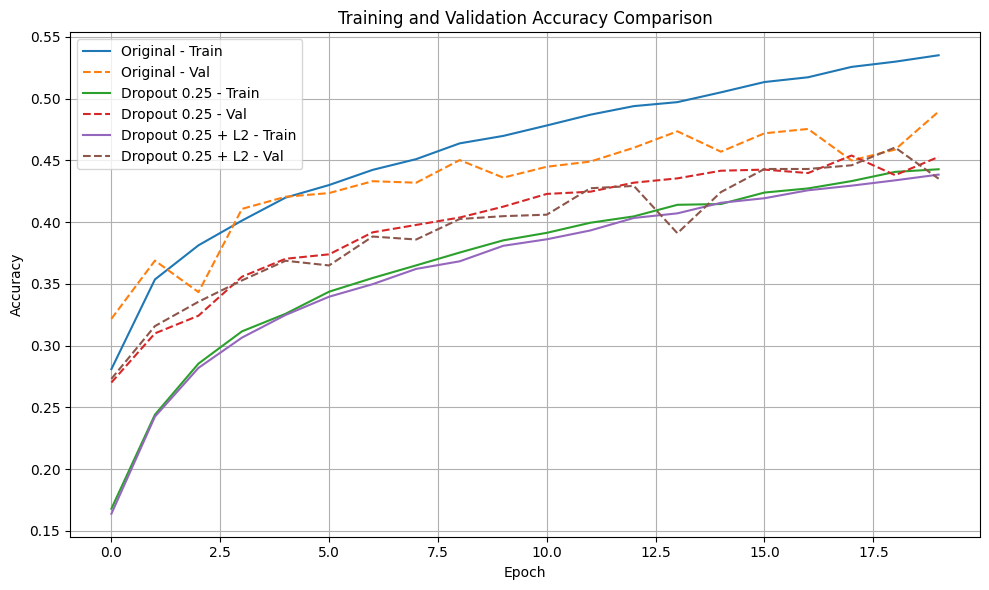

In [28]:
# 4.1: Original (no Dropout, no L2)
def build_model_original():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# 9.1: Dropout 0.25 after each hidden layer
def build_model_dropout():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,)),
        Dropout(0.25),
        Dense(512, activation='relu'),
        Dropout(0.25),
        Dense(256, activation='relu'),
        Dropout(0.25),
        Dense(128, activation='relu'),
        Dropout(0.25),
        Dense(10, activation='softmax')
    ])
    return model

# 9.2: Dropout 0.25 + L2 regularization (1e-4) on each Dense layer
def build_model_dropout_l2():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,), kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.25),
        Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.25),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.25),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.25),
        Dense(10, activation='softmax')
    ])
    return model

# Compile and train all three models, storing their history
histories = {}

# Original
model_orig = build_model_original()
model_orig.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
histories['Original'] = model_orig.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

# Dropout only
model_do = build_model_dropout()
model_do.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
histories['Dropout 0.25'] = model_do.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

# Dropout + L2
model_do_l2 = build_model_dropout_l2()
model_do_l2.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
histories['Dropout 0.25 + L2'] = model_do_l2.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

# Plot the comparison

plt.figure(figsize=(10,6))
for label, hist in histories.items():
    plt.plot(hist.history['accuracy'], label=f'{label} - Train')
    plt.plot(hist.history['val_accuracy'], linestyle='--', label=f'{label} - Val')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 10. Optimisers -Score: 1 mark

Modify the code written in section 5.2

1. RMSProp with your choice of hyper parameters
2. Adam with your choice of hyper parameters

Plot the comparison of the training and validation accuracy of the three (5.2, 10.1 and 10.2)


Epoch 1/20
313/313 - 3s - 11ms/step - accuracy: 0.2769 - loss: 2.0362 - val_accuracy: 0.3314 - val_loss: 1.9050
Epoch 2/20
313/313 - 4s - 11ms/step - accuracy: 0.3515 - loss: 1.8359 - val_accuracy: 0.3535 - val_loss: 1.8162
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.3828 - loss: 1.7534 - val_accuracy: 0.3841 - val_loss: 1.7315
Epoch 4/20
313/313 - 2s - 5ms/step - accuracy: 0.4023 - loss: 1.6980 - val_accuracy: 0.3273 - val_loss: 1.8680
Epoch 5/20
313/313 - 1s - 4ms/step - accuracy: 0.4168 - loss: 1.6564 - val_accuracy: 0.4028 - val_loss: 1.6850
Epoch 6/20
313/313 - 2s - 8ms/step - accuracy: 0.4297 - loss: 1.6150 - val_accuracy: 0.4062 - val_loss: 1.6681
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4403 - loss: 1.5870 - val_accuracy: 0.4105 - val_loss: 1.7039
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.4498 - loss: 1.5635 - val_accuracy: 0.4394 - val_loss: 1.5922
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4607 - loss: 1.5274 - val_accuracy: 0.4275 - val_loss: 1.6126

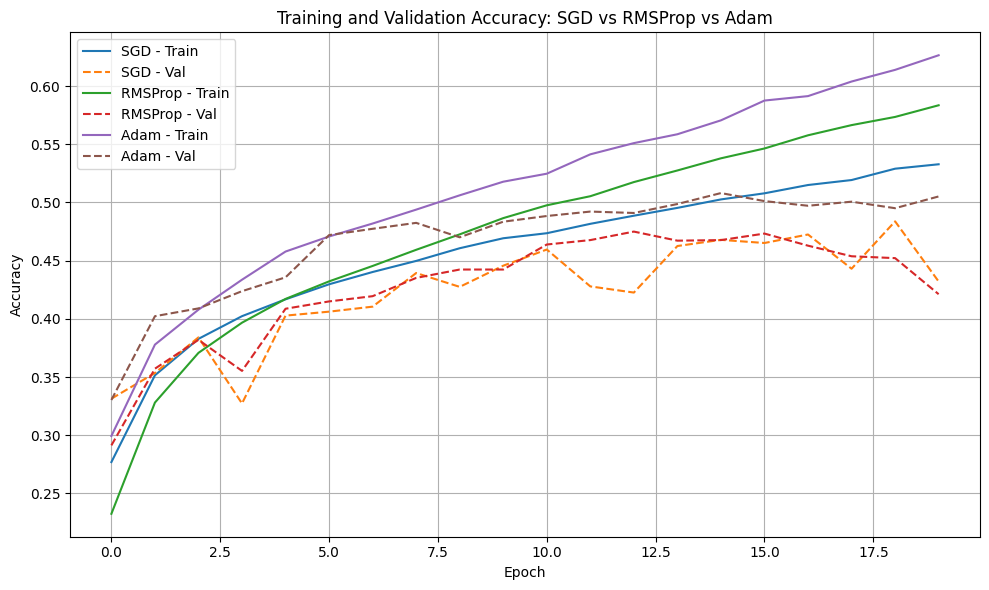

In [29]:
# Model builder function (same architecture for all)
def build_model():
    model = Sequential([
        Dense(1024, activation='relu', input_shape=(3072,)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

histories = {}

# SGD
model_sgd = build_model()
model_sgd.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)
histories['SGD'] = history_sgd

# RMSProp
model_rmsprop = build_model()
model_rmsprop.compile(optimizer=RMSprop(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
history_rmsprop = model_rmsprop.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)
histories['RMSProp'] = history_rmsprop

# Adam
model_adam = build_model()
model_adam.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(
    x_train_flat, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)
histories['Adam'] = history_adam

# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for label, hist in histories.items():
    plt.plot(hist.history['accuracy'], label=f'{label} - Train')
    plt.plot(hist.history['val_accuracy'], linestyle='--', label=f'{label} - Val')
plt.title('Training and Validation Accuracy: SGD vs RMSProp vs Adam')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# 11. Conclusion - Score: 1 mark

Comparing the sections 4.1, 5.2, 8, 9, and 10, present your observations on which model or architecture or regualiser or optimiser perfomed better.


# Observations based on different architectures and optimizers as tabulated below

#Section 4.1 (Base DNN Architecture, SGD):

This was our baseline deep neural network with five dense layers and the SGD optimizer.

It achieved moderate training and validation accuracy, but the learning was slower compared to adaptive optimizers.

Overfitting was limited, but overall accuracy was not very high.

#Section 5.2 (Optimizer: SGD):

Using SGD as the optimizer, we observed that the model converged slowly and sometimes got stuck at lower accuracy.

While SGD is a standard choice, it required careful tuning of the learning rate and did not adapt well to the complex CIFAR-10 dataset.

#Section 8 (Architectural Variations):

We experimented by decreasing and increasing the number of layers.

Decreasing one layer (shallower model) led to reduced accuracy, suggesting the model was underfitting and not capturing enough features.

Increasing one layer (deeper model) sometimes led to slight improvements but also increased the risk of overfitting and required more careful regularization and tuning.

The original architecture (from 4.1) provided the best balance between model complexity and performance.

#Section 9 (Regularization: Dropout and L2):

Adding Dropout (0.25) after each dense layer improved generalization and reduced overfitting, leading to slightly higher validation accuracy.

Combining Dropout (0.25) with L2 regularization (1e-4) further improved robustness and validation performance, especially when the model started to overfit.

The best results for regularization were seen when both Dropout and L2 were used together.

#Section 10 (Optimizers: SGD vs RMSProp vs Adam):

Adam optimizer consistently outperformed both SGD and RMSProp, achieving higher training and validation accuracy in fewer epochs.

RMSProp also performed better than SGD, especially in terms of faster convergence, but was slightly less stable than Adam.

SGD had the slowest convergence and lowest final accuracy among the three.